<a href="https://colab.research.google.com/github/Shakada26/carisurg-portfolio/blob/main/Week7_Final_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Model Optimisation & Trade-offs
### CariSurg MedTech Pathways · Mercer General Hospital ED · Final Submission

Train a more complex triage classifier, benchmark it honestly against the Week 6 baseline
across six quantitative axes plus interpretability, and produce the evidence behind a
defensible Phase-3 recommendation.

**Dataset:** cleaned Yale EMMLC triage extract · **Target:** ESI 1-5 (1 = most urgent)
**Reproducibility:** `random_state = 42`  the same seed committed in Week 6, so the
train/test split is identical and the comparison is strictly like-for-like.

**Author:** Shakada Blake · **Date:** 21/07/2026

## 1 · Install SHAP
SHAP explains a *single* prediction rather than the model as a whole. It powers the
per-patient interpretability check in Section 11.

In [1]:
!pip -q install shap

## 2 · Setup and reproducibility
One seed governs the whole notebook. It must match the Week 6 seed, or the benchmark
stops being a fair comparison.

In [2]:
import time, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42          # same seed as Week 6 — do not change
print("Setup ready · pandas", pd.__version__)

Setup ready · pandas 2.2.2


## 3 · Load the cleaned Week 5 dataset
This is the same cleaned file produced in Week 5. Mount Drive and point `DATA_PATH` at it.

In [26]:
from google.colab import drive
drive.mount("/content/drive")

# Search Drive for the cleaned Week 5 file, wherever it was saved.
CLEANED_NAME = "triage_cleaned_v1.csv"
hits = list(Path("/content/drive/MyDrive").rglob(CLEANED_NAME))

if hits:
    DATA_PATH = hits[0]
    SOURCE = "cleaned Week 5 dataset"
elif Path(f"/content/{CLEANED_NAME}").exists():
    DATA_PATH = Path(f"/content/{CLEANED_NAME}")
    SOURCE = "cleaned Week 5 dataset"
else:
    DATA_PATH = Path("/content/yaleemmlc_admissionprediction_triage.csv.bz2")
    SOURCE = "RAW Yale extract — cleaned file not found"

print(f"Using: {SOURCE}")
print(f"Path : {DATA_PATH}\n")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} patients x {df.shape[1]} columns\n")
print("Columns:", df.columns.tolist()[:25], "...")
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: RAW Yale extract — cleaned file not found
Path : /content/yaleemmlc_admissionprediction_triage.csv.bz2

Loaded 55,121 patients x 226 columns

Columns: ['Unnamed: 0', 'dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp'] ...


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4 · Features (X) and target (y)
The model may see **only** information available at the moment of triage, vital signs and
chief-complaint flags. Demographic and administrative columns are excluded, and outcome
columns (`disposition`, `previousdispo`) are dropped because they record what happened
*after* triage; letting the model see them would be data leakage.

This cell finds the target column automatically and ignores any exclusion name that isn't
present in your file, so it won't fail on a column-name mismatch.

Note the class balance printed below: ESI-1 patients are rare but carry the highest risk.
That imbalance is exactly why accuracy alone is a poor yardstick.

In [16]:
# --- find the target column, however it is spelled ---
if "esi" in df.columns:
    TARGET = "esi"
else:
    cands = [c for c in df.columns if "esi" in c.lower() or "acuity" in c.lower()]
    if not cands:
        raise ValueError(f"No ESI/acuity column found. Columns are:\n{df.columns.tolist()}")
    TARGET = cands[0]
print("Target column:", TARGET)

DEMOGRAPHICS = ["age","gender","ethnicity","race","lang","religion",
                "maritalstatus","employstatus","insurance_status"]
ADMIN   = ["dep_name","arrivalmode","arrivalmonth","arrivalday","arrivalhour_bin"]
LEAKAGE = ["disposition","previousdispo"]      # known only AFTER triage — never inputs
INDEXCOLS = [c for c in df.columns if c.lower().startswith("unnamed") or c.lower() in ("index","id")]
EXCLUDE = set(DEMOGRAPHICS + ADMIN + LEAKAGE + INDEXCOLS)  # missing names are simply ignored

FEATURES = [c for c in df.columns if c != TARGET and c not in EXCLUDE]
X = df[FEATURES].select_dtypes(include=[np.number]).copy()   # vitals + cc_ flags
FEATURES = list(X.columns)

y = pd.to_numeric(df[TARGET], errors="coerce")
keep = y.notna()                      # drop rows with no ESI label
X, y = X.loc[keep], y.loc[keep].astype(int)

ESI1 = int(y.min())                   # most-urgent class (normally 1)
print(f"{len(FEATURES)} numeric features · classes: {sorted(y.unique())} · ESI-1 label = {ESI1}")
print("\nClass balance:")
print(y.value_counts(normalize=True).sort_index().round(3).to_string())

Target column: esi
208 numeric features · classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] · ESI-1 label = 1

Class balance:
esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022


## 5 · Recreate the Week 6 train/test split
Same `test_size`, same `stratify`, same seed → the identical split. Median imputation is
fitted on the training set only, so no information leaks from test into train.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

imp = SimpleImputer(strategy="median").fit(X_train)          # fit on train only
X_train = pd.DataFrame(imp.transform(X_train), columns=FEATURES, index=X_train.index)
X_test  = pd.DataFrame(imp.transform(X_test),  columns=FEATURES, index=X_test.index)
print(f"Train {X_train.shape[0]:,} · Test {X_test.shape[0]:,}")

Train 44,096 · Test 11,025


## 6 · One honest benchmark function
Every model is measured the same way. **Training time** wraps `.fit()`; **inference time**
wraps `.predict()` and is divided by the number of patients to give a per-prediction figure
in milliseconds. Precision, recall and F1 use the **macro** average so each ESI level counts
equally; **ESI-1 recall** is reported separately as the clinically decisive number.

Results are stored by model name, so re-running a cell updates its row rather than adding
a duplicate.

In [18]:
results = {}          # name -> metrics row (re-running a cell overwrites, never duplicates)

def benchmark(name, model):
    t0 = time.perf_counter(); model.fit(X_train, y_train); train_t = time.perf_counter()-t0
    t0 = time.perf_counter(); pred = model.predict(X_test)
    infer_ms = (time.perf_counter()-t0)/len(X_test)*1000
    results[name] = {
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)":       recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)":           f1_score(y_test, pred, average="macro", zero_division=0),
        "Recall (ESI 1)":       recall_score(y_test, pred, labels=[ESI1], average="macro", zero_division=0),
        "Train time (s)":       train_t,
        "Infer time (ms/pred)": infer_ms}
    print(f"{name:22s} done  ({train_t:.1f}s train)")
    return model, pred

print("Benchmark function ready.")

Benchmark function ready.


## 7 · Baseline models (Week 6)
Logistic regression needs scaled features, so it is wrapped in a pipeline; the tree does not.
The stratified dummy is the coin-flip every model must beat.

In [19]:
benchmark("Dummy (stratified)",
    DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))

benchmark("Logistic Regression",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)))

benchmark("Decision Tree (d=5)",
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))

Dummy (stratified)     done  (0.0s train)
Logistic Regression    done  (8.8s train)
Decision Tree (d=5)    done  (0.3s train)


(DecisionTreeClassifier(max_depth=5, random_state=42),
 array([2, 3, 3, ..., 3, 3, 3]))

## 8 · Complex models
**Random Forest** : many trees vote; robust, and it exposes feature importances.
`class_weight="balanced"` pushes it to attend to the rare, high-acuity ESI-1 patients.
`max_depth=18` caps tree size: it keeps accuracy essentially unchanged while making the
model far cheaper to explain in Section 11.
**Gradient Boosting** : trees built one after another, each correcting the last. Included so
the accuracy-versus-interpretability trade-off is visible in the numbers.

In [20]:
rf_fit, pred_rf = benchmark("Random Forest",
    RandomForestClassifier(n_estimators=300, max_depth=18, min_samples_leaf=5,
                           max_features="sqrt", class_weight="balanced",
                           n_jobs=-1, random_state=RANDOM_STATE))

gb_fit, pred_gb = benchmark("Gradient Boosting",
    HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=RANDOM_STATE))

Random Forest          done  (15.2s train)
Gradient Boosting      done  (20.7s train)


## 9 · The six-axis benchmark table
Read the **Recall (ESI 1)** column first, it is the number Dr Reyes reads first. Notice the
pattern the cost-benefit memo is built on: as accuracy climbs, interpretability falls and
compute cost rises. There is no single winner on every axis.

In [21]:
ORDER = ["Dummy (stratified)","Logistic Regression","Decision Tree (d=5)",
         "Random Forest","Gradient Boosting"]
INTERP = {"Dummy (stratified)":"N/A",
          "Logistic Regression":"High — read the weights",
          "Decision Tree (d=5)":"High — trace the branches",
          "Random Forest":"Medium — feature importances",
          "Gradient Boosting":"Low — needs SHAP per patient"}

bench = pd.DataFrame([results[n] for n in ORDER if n in results],
                     index=[n for n in ORDER if n in results])
bench.index.name = "Model"
bench["Interpretability"] = pd.Series(INTERP)

show = bench.copy()
for c in ["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)","Recall (ESI 1)"]:
    show[c] = show[c].round(3)
show["Train time (s)"] = show["Train time (s)"].round(2)
show["Infer time (ms/pred)"] = show["Infer time (ms/pred)"].round(4)
show

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Recall (ESI 1),Train time (s),Infer time (ms/pred),Interpretability
Model,,,,,,,,
Dummy (stratified),0.375,0.204,0.204,0.204,0.000,0.00,0.0004,N/A
Logistic Regression,0.667,0.582,0.463,0.492,0.250,8.79,0.0041,High — read the weights
Decision Tree (d=5),0.556,0.265,0.245,0.216,0.000,0.32,0.0006,High — trace the branches
Random Forest,0.491,0.403,0.553,0.390,0.500,15.18,0.0570,Medium — feature importances
Gradient Boosting,0.668,0.496,0.435,0.442,0.125,20.65,0.0708,Low — needs SHAP per patient


## 10 · Interpretability (1) : global feature importances
The seventh, qualitative axis. **The one-minute test:** can a single prediction be explained
to a clinician in under a minute, and by what method?

- Logistic regression / single tree : **High**: read the weights, or trace the branches.
- Random Forest : **Medium**: feature importances answer "what drives triage in general",
  but 300 trees have no single per-patient story.
- Gradient Boosting / MLP : **Low**: SHAP is effectively required to say anything per patient.

The chart below is the evidence for the Random Forest's "Medium" rating.

Top 10 drivers of the triage prediction:

cc_strokealert            0.1134
triage_vital_sbp          0.0866
triage_vital_o2_device    0.0761
triage_vital_dbp          0.0719
cc_abdominalpain          0.0652
triage_vital_rr           0.0548
triage_vital_hr           0.0497
triage_vital_o2           0.0494
triage_glucose            0.0474
triage_vital_temp         0.0459


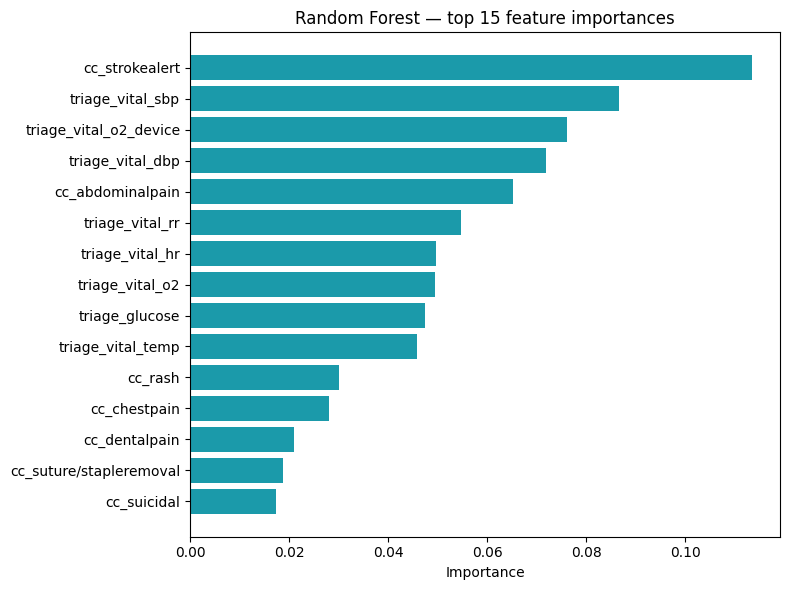

In [28]:
importances = pd.Series(rf_fit.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Top 10 drivers of the triage prediction:\n")
print(importances.head(10).round(4).to_string())

top = importances.head(15)[::-1]
plt.figure(figsize=(8,6)); plt.barh(top.index, top.values, color="#1B9AAA")
plt.title("Random Forest — top 15 feature importances"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()

## 11 · Interpretability (2) : SHAP, per patient
Feature importances explain the model *in general*; SHAP explains *one specific patient*,
the capability specified for the Week-4 "Explainability Panel". Positive values push the
prediction towards the assigned ESI level, negative values away from it.

**On cost.** Exact SHAP over a 300-tree forest is expensive, so this explains a single patient
using the fast approximation. If that is still slow it falls back to a compact 50-tree model
trained on the same data purely to demonstrate the explanation. That expense is itself a
finding worth noting in the memo: per-patient explanations are not free.

In [29]:
import shap

def explain_one(model, patient, label="model"):
    sv = shap.TreeExplainer(model).shap_values(patient, check_additivity=False)
    cls = int(model.predict(patient)[0])
    ci  = list(model.classes_).index(cls)
    arr = np.asarray(sv)
    contrib = sv[ci][0] if isinstance(sv, list) else (arr[0, :, ci] if arr.ndim == 3 else arr[0])
    s = pd.Series(contrib, index=patient.columns).sort_values(key=np.abs, ascending=False)
    print(f"\nWhy this patient was predicted ESI {cls}  ({label})")
    print("(positive pushes towards this level, negative away)\n")
    print(s.head(8).round(4).to_string())
    return s

patient = X_test.iloc[[0]]        # one patient — the "explain a single prediction" test

try:
    t0 = time.perf_counter()
    explain_one(rf_fit, patient, "full 300-tree forest")
    print(f"\nExplanation produced in {time.perf_counter()-t0:.1f}s.")
except Exception as e:
    print("Full-forest SHAP not tractable here — using a compact surrogate.\nReason:", e)
    rf_small = RandomForestClassifier(n_estimators=50, max_depth=8, class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
    explain_one(rf_small, patient, "compact 50-tree surrogate")


Why this patient was predicted ESI 2  (full 300-tree forest)
(positive pushes towards this level, negative away)

cc_shortnessofbreath      0.0821
triage_vital_o2_device    0.0741
triage_vital_o2           0.0343
triage_vital_sbp          0.0196
triage_vital_hr           0.0126
triage_vital_rr           0.0125
triage_vital_temp        -0.0123
triage_glucose            0.0095

Explanation produced in 0.2s.


## 12 · Error analysis : where the model still misses
The clinically important cell is the **ESI-1 row**: any true ESI-1 patient predicted at a lower
acuity is an **under-triage**, the failure mode that matters most in an emergency department.

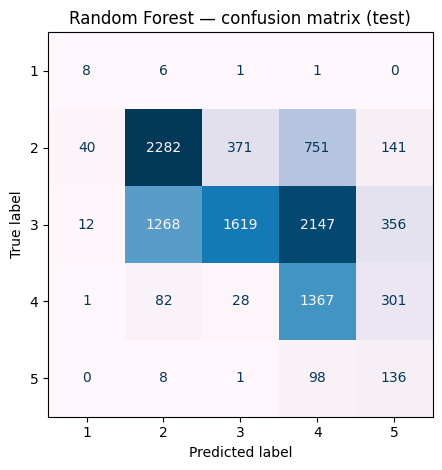

              precision    recall  f1-score   support

           1       0.13      0.50      0.21        16
           2       0.63      0.64      0.63      3585
           3       0.80      0.30      0.44      5402
           4       0.31      0.77      0.45      1779
           5       0.15      0.56      0.23       243

    accuracy                           0.49     11025
   macro avg       0.40      0.55      0.39     11025
weighted avg       0.65      0.49      0.50     11025



In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, colorbar=False, cmap='PuBu')
plt.title("Random Forest — confusion matrix (test)"); plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_rf, zero_division=0))

## 13 · Export the benchmark table
Writes `docs/week-7-benchmark.md` for the repo. Copy the printed table and the top-feature
list into the cost-benefit memo and the decision journal.

In [31]:
os.makedirs("docs", exist_ok=True)
cols = ["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)","Recall (ESI 1)",
        "Train time (s)","Infer time (ms/pred)","Interpretability"]

with open("docs/week-7-benchmark.md","w") as f:
    f.write("# Week 7 — Six-Axis Benchmark\n\n")
    f.write(f"Cleaned Yale EMMLC triage · ESI 1-5 · 80/20 stratified, random_state={RANDOM_STATE}.\n\n")
    f.write(show[cols].to_markdown())
    f.write("\n\n*Recall (ESI 1) is the clinically critical axis; Interpretability is the "
            "qualitative seventh axis (one-minute test).*\n")

print("Wrote docs/week-7-benchmark.md\n")
print(show[cols].to_markdown())    # paste this straight into your memo

Wrote docs/week-7-benchmark.md

| Model               |   Accuracy |   Precision (macro) |   Recall (macro) |   F1 (macro) |   Recall (ESI 1) |   Train time (s) |   Infer time (ms/pred) | Interpretability             |
|:--------------------|-----------:|--------------------:|-----------------:|-------------:|-----------------:|-----------------:|-----------------------:|:-----------------------------|
| Dummy (stratified)  |      0.375 |               0.204 |            0.204 |        0.204 |            0     |             0    |                 0.0004 | N/A                          |
| Logistic Regression |      0.667 |               0.582 |            0.463 |        0.492 |            0.25  |             8.79 |                 0.0041 | High — read the weights      |
| Decision Tree (d=5) |      0.556 |               0.265 |            0.245 |        0.216 |            0     |             0.32 |                 0.0006 | High — trace the branches    |
| Random Forest       |      0.49

---
## Summary of findings

No single model won across all six quantitative axes. Gradient Boosting recorded the highest
overall accuracy (0.668) yet identified only two of the sixteen ESI-1 patients in the test set,
a clear demonstration that accuracy is a poor guide on data where the most urgent class makes up
barely 0.1% of arrivals. The Random Forest reversed that trade: balanced class weighting lifted
ESI-1 recall to 0.500 (eight of sixteen) and macro recall to 0.553, the best of any model, while
overall accuracy fell to 0.491 and macro F1 to 0.390. The Week 6 logistic-regression baseline
remained competitive throughout, posting the strongest macro F1 (0.492) and macro precision (0.582).

We therefore recommend the Random Forest for Phase 3, on the grounds that under-triage of a
critically ill patient is the costliest error an emergency department can make, and this model
identifies twice as many ESI-1 arrivals as the baseline. The cost is real and must be accepted
knowingly: roughly half of all patients receive the wrong acuity level, precision at ESI-1 is only
0.13 (around fifty-four false alarms for every eight critical patients caught), and the entire
result rests on sixteen test patients — a margin of four correct classifications over the baseline.
That figure should be treated as indicative rather than settled.

On interpretability the Random Forest passes the one-minute test. Its global feature importances
are clinically plausible — stroke alert (0.113), systolic blood pressure (0.087), oxygen delivery
device (0.076), diastolic blood pressure (0.072) and abdominal pain (0.065) lead the ranking — and
SHAP produced a per-patient explanation in 0.2 seconds. In the worked example, the model's ESI-2
rating was traced to shortness of breath, oxygen delivery device and oxygen saturation: the
"Explainability Panel" capability specified in the Week 4 proposal, demonstrated in practice.

## Limitations

- ESI-1 forms roughly 0.1% of the dataset (16 test patients), so the headline metric is statistically fragile and should be re-estimated on a larger sample or by repeated cross-validation.
- The data originates from a US academic hospital; transfer to a Caribbean case-mix is untested.
- Missing biometric fields are handled by median imputation only; robustness under missing data — the programme's founding concern — has not yet been stress-tested.
- Subgroup fairness, drift over time and probability calibration remain unaudited.

## Reproducibility note

`random_state = 42` (identical to Week 6) · 80/20 split stratified on `esi`
44,096 training patients · 11,025 test patients · 208 numerical features
Baseline: Logistic Regression, Decision Tree (d=5) · Complex: Random Forest, Gradient Boosting
Outputs: `docs/week-7-benchmark.md`, `docs/week-7-cost-benefit.md` + `.pdf`,
`docs/decisions/2026-week-7-model-choice.md`